# Política de baseline — janela móvel ou acumulativo?

O detector é retreinado no dia 1º de cada mês, 15 vezes entre fev/2025 e abr/2026.
Este notebook responde **que histórico entra em cada retreino**: tudo o que já
aconteceu (acumulativo), ou só as últimas *N* horas de operação (janela móvel).

A pergunta apareceu na reunião com o líder técnico, que pediu para abandonar o
acumulativo e sugeriu janelas de *N meses*. Aqui as duas coisas são testadas: a
janela em horas de operação e a janela em meses de calendário.

**Como a comparação é feita:** fronteira contra fronteira, nunca ponto contra ponto.
Cada política tem centenas de configurações de limiar, suavização e persistência;
comparar a "melhor de cada uma" em um limiar fixo seria inválido, porque uma janela
maior desloca a distribuição do score e o mesmo percentil passa a ser outro ponto
de operação. O que se compara é o **envelope**: para cada nível de detecção, o menor
falso positivo que aquela política consegue.

Fonte: três tasks do ClearML, 60.048 configurações no total.

---
## 1. A fronteira de cada política

Cada linha é uma política de baseline. O eixo horizontal é o falso positivo, o
vertical é quantos dos 8 eventos foram antecipados. Para cada nível de detecção a
linha marca o **menor falso positivo que aquela política alcança** — é o melhor que
ela pode fazer, não uma configuração específica.

A linha grossa cinza é o **acumulativo**, o que roda hoje no notebook 06. Uma
política só interessa se a curva dela passa por cima e à esquerda dessa.

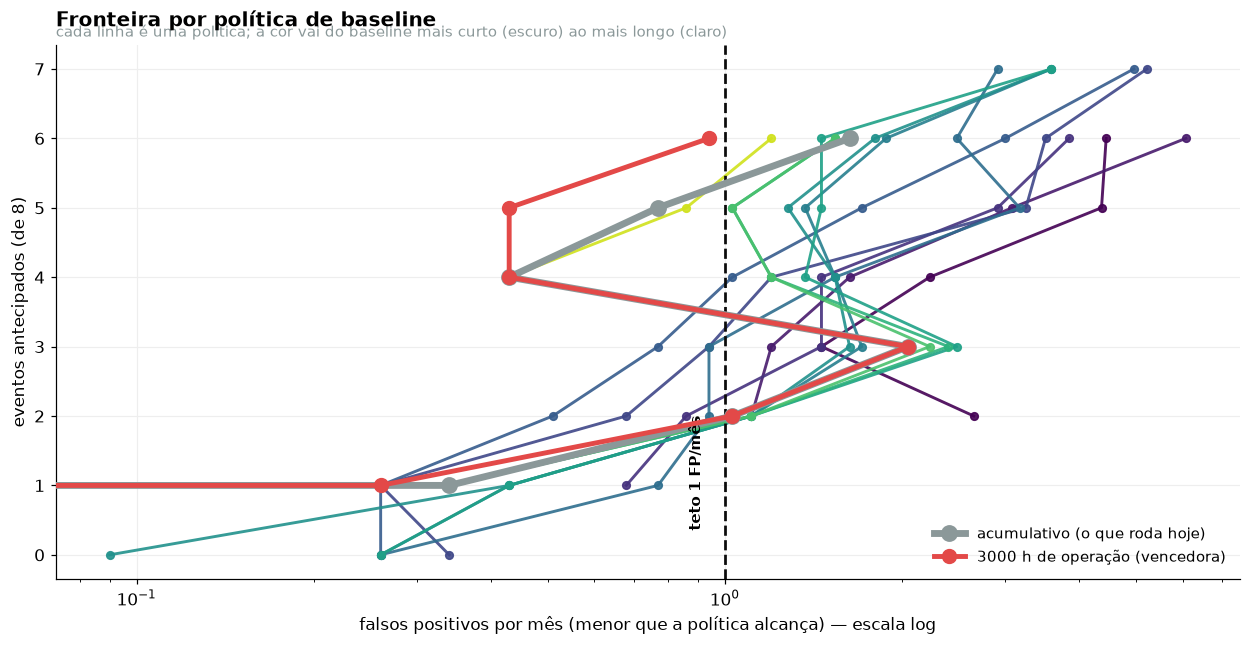

In [2]:
def fronteira(tabela: pd.DataFrame) -> pd.Series:
    """Menor FP/mês alcançado em cada nível de detecção — o envelope da política.

    Usar o mínimo e não a média é o ponto: a política é julgada pelo que ela
    permite no seu melhor ajuste, já que os fatores baratos (limiar, suavização,
    persistência) são livres e serão escolhidos depois.
    """
    return tabela.groupby("eventos_detectados")["fp_por_mes"].min()


# ordena as políticas pelo tamanho médio de baseline que elas realmente entregaram,
# e não pelo rótulo: '3000h' truncado vale menos histórico do que o nome sugere
ordem_politicas = (pol.groupby("trial.baseline_label")["baseline_horas_medio"]
                      .mean().sort_values().index.tolist())
mapa = plt.get_cmap("viridis")
cores = {rot: mapa(i / max(len(ordem_politicas) - 1, 1))
         for i, rot in enumerate(ordem_politicas)}

fig, ax = plt.subplots(figsize=(11.5, 6))
for rotulo in ordem_politicas:
    curva = fronteira(pol[pol["trial.baseline_label"] == rotulo])
    if rotulo == "acum":
        ax.plot(curva.values, curva.index, color=CINZA, lw=4.5, marker="o", ms=10,
                zorder=3, label="acumulativo (o que roda hoje)")
    else:
        ax.plot(curva.values, curva.index, color=cores[rotulo], lw=1.9, marker="o",
                ms=5, alpha=0.9, zorder=2)

melhor = fronteira(pol[pol["trial.baseline_label"] == "3000h"])
ax.plot(melhor.values, melhor.index, color=VERM, lw=3.2, marker="o", ms=9,
        zorder=4, label="3000 h de operação (vencedora)")

ax.axvline(TETO_FP, color=TINTA, ls="--", lw=1.8)
ax.text(TETO_FP - 0.08, 0.4, f"teto {TETO_FP:g} FP/mês", rotation=90, ha="right",
        fontsize=9.5, fontweight="bold")
ax.set_xscale("log")
ax.set_xlabel("falsos positivos por mês (menor que a política alcança) — escala log")
ax.set_ylabel("eventos antecipados (de 8)")
ax.set_yticks(range(0, 8))
ax.set_title("Fronteira por política de baseline", loc="left", fontweight="bold",
             fontsize=13, pad=12)
ax.text(0, 1.015, "cada linha é uma política; a cor vai do baseline mais curto (escuro) "
        "ao mais longo (claro)", transform=ax.transAxes, fontsize=9.5, color=CINZA)
ax.legend(frameon=False, loc="lower right", fontsize=10)
fig.tight_layout()
plt.show()

---
## 2. Existe um ótimo interior?

A intuição diz que a curva é monótona: mais histórico, melhor. Se for isso, o
acumulativo ganha e não há discussão. O gráfico abaixo testa a hipótese diretamente
— detecção máxima **dentro do teto de falso positivo**, contra o tamanho da janela.

Os pontos vermelhos são o estágio 1 (varredura grossa, 7 janelas). Os pontos azuis
são o estágio 3 (refino, 5 janelas com grade de 30 s e 2 min e três arquiteturas,
51.840 configurações). A linha laranja tracejada é o acumulativo.

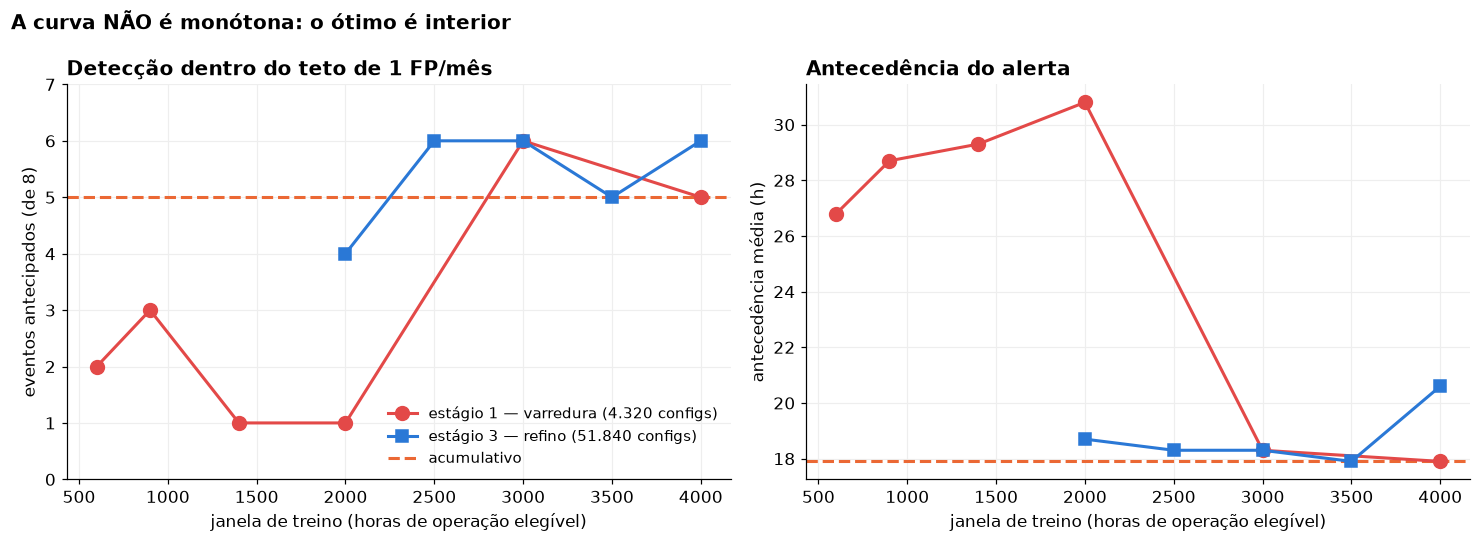

estágio 1 (varredura grossa)
                             eventos_detectados  lead_medio_h  fp_por_mes  retreinos_truncados
trial.baseline.window_hours                                                                   
600.0                                         2          26.8         0.9                    1
900.0                                         3          28.7         0.9                    1
1400.0                                        1          29.3         0.9                    2
2000.0                                        1          30.8         0.9                    4
3000.0                                        6          18.3         0.9                    6
4000.0                                        5          17.9         0.9                    8

estágio 3 (refino)
                             eventos_detectados  lead_medio_h  fp_por_mes  retreinos_truncados
trial.baseline.window_hours                                                                   
2

In [3]:
def detecao_no_teto(tabela: pd.DataFrame, chave: str) -> pd.DataFrame:
    """Detecção máxima e melhor lead sob o teto de FP, por valor de `chave`."""
    dentro = tabela[tabela.aprovado]
    return (dentro.sort_values(["eventos_detectados", "lead_medio_h"], ascending=False)
                  .groupby(chave).head(1)
                  .set_index(chave)[["eventos_detectados", "lead_medio_h",
                                     "fp_por_mes", "retreinos_truncados"]]
                  .sort_index())


# só as janelas puras em horas: as em dias e as híbridas entram na seção 3
horas_pol = pol[pol["trial.baseline.window_hours"].notna()
                & pol["trial.baseline.max_age_days"].isna()]
grosso = detecao_no_teto(horas_pol, "trial.baseline.window_hours")
refino = detecao_no_teto(fino, "trial.baseline.window_hours")
acum = detecao_no_teto(pol[pol["trial.baseline_label"] == "acum"], "trial.baseline_label")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5), sharex=True)

for eixo, coluna, rotulo in [(ax1, "eventos_detectados", "eventos antecipados (de 8)"),
                             (ax2, "lead_medio_h", "antecedência média (h)")]:
    eixo.plot(grosso.index, grosso[coluna], color=VERM, lw=2, marker="o", ms=9,
              zorder=3, label="estágio 1 — varredura (4.320 configs)")
    eixo.plot(refino.index, refino[coluna], color=AZUL, lw=2, marker="s", ms=8,
              zorder=4, label="estágio 3 — refino (51.840 configs)")
    eixo.axhline(acum[coluna].iloc[0], color=LARJ, ls="--", lw=2, zorder=2,
                 label="acumulativo")
    eixo.set_xlabel("janela de treino (horas de operação elegível)")
    eixo.set_ylabel(rotulo)

ax1.set_yticks(range(0, 8))
ax1.legend(frameon=False, fontsize=9.5, loc="lower right")
ax1.set_title("Detecção dentro do teto de 1 FP/mês", loc="left", fontweight="bold")
ax2.set_title("Antecedência do alerta", loc="left", fontweight="bold")
fig.suptitle("A curva NÃO é monótona: o ótimo é interior", x=0.005, ha="left",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

print("estágio 1 (varredura grossa)")
print(grosso.round(1).to_string())
print("\nestágio 3 (refino)")
print(refino.round(1).to_string())
print(f"\nacumulativo: {int(acum.eventos_detectados.iloc[0])}/8 eventos, "
      f"lead {acum.lead_medio_h.iloc[0]:.1f} h, FP {acum.fp_por_mes.iloc[0]:.2f}/mês")

**Leitura.** Janela curta (≤ 2.000 h) perde eventos e o ganho sobre o acumulativo é de
**um evento** — modesto, mas real, e sem custo de falso positivo.

Cuidado com a forma da curva, porém: ela **não** é um platô limpo que cai depois. No
refino, 2.500 h e 3.000 h dão 6/8, 3.500 h cai para 5/8 e 4.000 h volta para 6/8. Um
degrau para baixo cercado por dois iguais é sinal de que, nessa resolução, as
diferenças estão dentro do ruído da grade — não de que 3.500 h seja pior por algum
motivo físico. O que a figura sustenta é a faixa "2.500 a 4.000 h", não um valor.

Os dois pontos de 6/8 nos extremos dessa faixa não são equivalentes, e a diferença não
aparece na detecção:

| candidata | eventos | lead | trimestres com alerta | maior silêncio | truncados |
|---|---|---|---|---|---|
| PCA, 3.000 h | 6/8 | 18,3 h | **6 de 6** | 2.253 h | 6 |
| autoencoder, 4.000 h | 6/8 | **20,6 h** | 4 de 6 | 3.777 h | 8 |

O autoencoder antecipa 2,3 h mais, mas fica dois trimestres inteiros sem emitir nada e
com 1.500 h a mais de silêncio. Entre as duas, a que se defende na operação é a do PCA.

---
## 3. Horas de operação ou meses de calendário?

O líder técnico sugeriu janela de *N meses*. Vale testar, porque é a formulação mais
natural para quem opera. Mas há um problema medido nesta série: **um mês de calendário
entrega entre 133,8 h e 691,1 h de operação** — uma variação de 5,17×.

Pior, a escassez é *endógena às falhas*: a correlação entre falhas nos 45 dias
anteriores e horas elegíveis nos 30 dias seguintes é **−0,61**. Quer dizer que contar
em meses encolhe o baseline exatamente nos retreinos que vêm depois de um reparo —
justo quando o modelo mais precisa de referência.

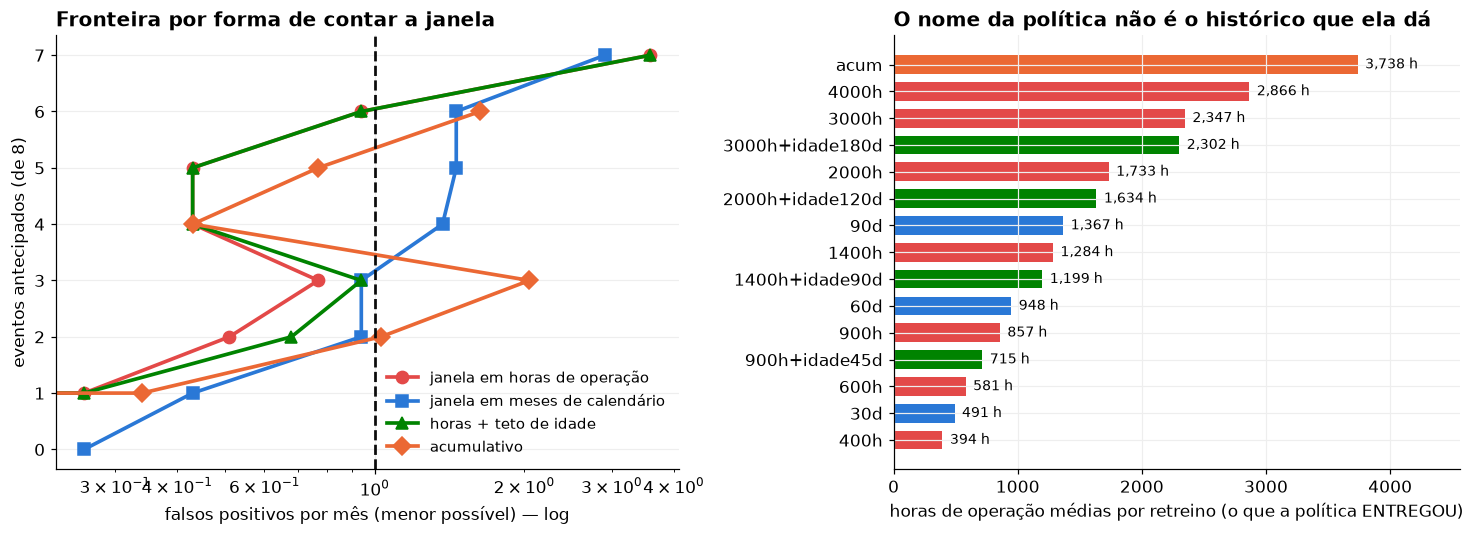

melhor detecção dentro do teto, por forma de contar:
  janela em horas de operação      6/8
  janela em meses de calendário    3/8
  horas + teto de idade            6/8
  acumulativo                      5/8


In [4]:
modos = {"movel": ("janela em horas de operação", VERM, "o"),
         "dias": ("janela em meses de calendário", AZUL, "s"),
         "hibrido": ("horas + teto de idade", VERD, "^"),
         "acumulativo": ("acumulativo", LARJ, "D")}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5),
                               gridspec_kw={"width_ratios": [1.1, 1]})

for modo, (rotulo, cor, marca) in modos.items():
    sub = pol[pol["trial.baseline_mode"] == modo]
    if sub.empty:
        continue
    curva = fronteira(sub)
    ax1.plot(curva.values, curva.index, color=cor, lw=2.4, marker=marca, ms=8,
             label=rotulo)

ax1.axvline(TETO_FP, color=TINTA, ls="--", lw=1.8)
ax1.set_xscale("log")
ax1.set_xlabel("falsos positivos por mês (menor possível) — log")
ax1.set_ylabel("eventos antecipados (de 8)")
ax1.set_yticks(range(0, 8))
ax1.legend(frameon=False, fontsize=10, loc="lower right")
ax1.set_title("Fronteira por forma de contar a janela", loc="left", fontweight="bold")

# quanto histórico cada rótulo REALMENTE entregou, contra o que o nome promete
entregue = (pol.groupby(["trial.baseline_mode", "trial.baseline_label"])
               ["baseline_horas_medio"].mean().reset_index())
entregue = entregue.sort_values("baseline_horas_medio")
cor_barra = [modos[m][1] for m in entregue["trial.baseline_mode"]]
ax2.barh(entregue["trial.baseline_label"], entregue["baseline_horas_medio"],
         color=cor_barra, height=0.7)
for _, linha in entregue.iterrows():
    ax2.text(linha.baseline_horas_medio + 60, linha["trial.baseline_label"],
             f"{linha.baseline_horas_medio:,.0f} h", va="center", fontsize=9)
ax2.set_xlabel("horas de operação médias por retreino (o que a política ENTREGOU)")
ax2.set_xlim(0, entregue.baseline_horas_medio.max() * 1.22)
ax2.set_title("O nome da política não é o histórico que ela dá", loc="left",
              fontweight="bold")
fig.tight_layout()
plt.show()

print("melhor detecção dentro do teto, por forma de contar:")
for modo in modos:
    sub = pol[(pol["trial.baseline_mode"] == modo) & pol.aprovado]
    if not sub.empty:
        print(f"  {modos[modo][0]:32s} {int(sub.eventos_detectados.max())}/8")

**Leitura.** Contar em meses vai na direção errada: 60 dias chega a 3/8 e 90 dias a
1/8, contra 6/8 das 3.000 h de operação. E 30 dias — a janela mais próxima da
sugestão original — não tem **nenhuma** configuração dentro do teto de falso positivo.

O painel da direita mostra por que os rótulos enganam: `90d` entrega em média **1.367 h**
de operação, contra 2.347 h de `3000h`. Comparar "3 meses" com "3.000 horas" como se
fossem alternativas do mesmo tamanho é o erro a evitar na conversa com a operação.

Duas políticas não têm **nenhuma** configuração dentro do teto de falso positivo, em
288 tentativas cada: `30d` e `400h`. Vale registrar que `400h` é a janela que roda hoje
no notebook 06 — ela aparecia aprovada na grade antiga porque lá os fatores baratos
eram outros, não porque a janela em si seja viável nesta varredura.

O modo híbrido (janela em horas **e** teto de idade) não acrescentou nada:
`3000h+idade180d` dá o mesmo 6/8, o mesmo lead de 18,3 h e o mesmo FP de 0,94 que
`3000h`, porque 180 dias nunca chegam a limitar 3.000 h de operação nesta série. O teto
de idade é um eixo inerte e pode sair da grade.

---
## 4. A ressalva que muda a leitura: truncagem

A série de treino começa em jan/2025. No retreino de fev/2025 não existem 3.000 h de
operação passadas para pegar — existem ~300. Quando a janela pedida é maior que o
histórico disponível, ela é **truncada**, e naquele retreino a "janela móvel" é na
prática o acumulativo.

Isso não invalida o resultado, mas limita o que ele significa: parte do ganho das
3.000 h vem de retreinos que não eram móveis de verdade.

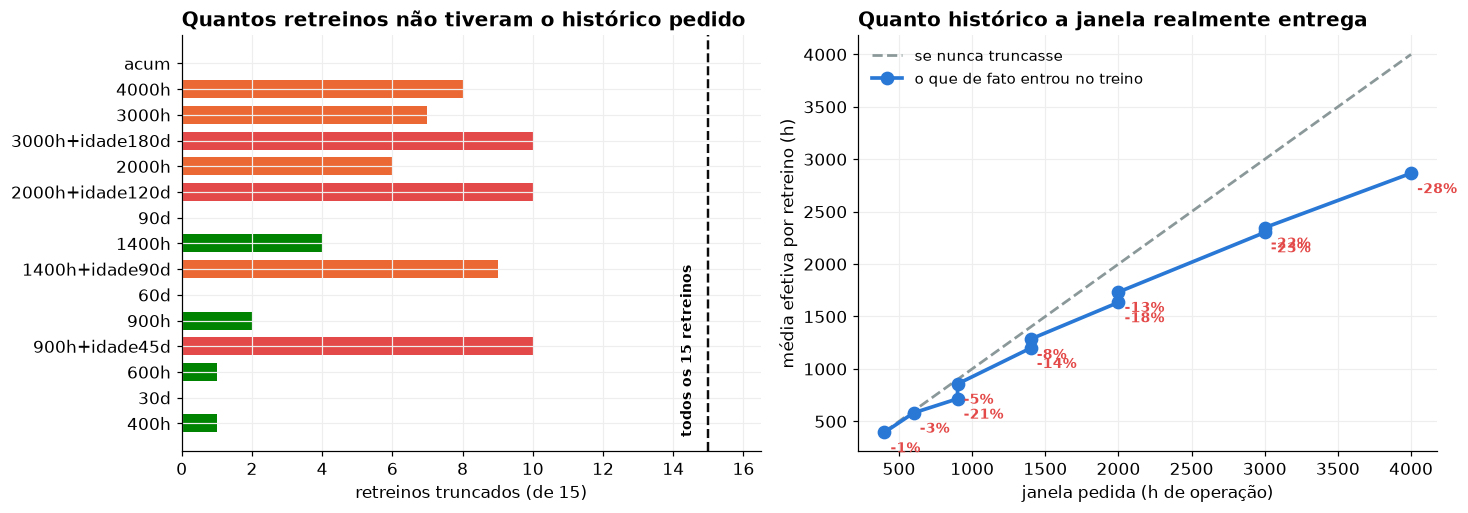

                      truncados  horas_pedidas  horas_entregues  span_dias
trial.baseline_label                                                      
400h                          1          400.0            394.1       24.8
30d                           0            NaN            491.1       26.2
600h                          1          600.0            580.8       37.1
900h+idade45d                10          900.0            715.2       41.0
900h                          2          900.0            856.8       52.4
60d                           0            NaN            948.4       53.6
1400h+idade90d                9         1400.0           1198.6       70.2
1400h                         4         1400.0           1284.4       78.2
90d                           0            NaN           1367.1       79.4
2000h+idade120d              10         2000.0           1634.4       96.4
2000h                         6         2000.0           1733.2      105.3
3000h+idade180d          

In [5]:
trunc = (pol.groupby("trial.baseline_label")
            .agg(truncados=("retreinos_truncados", "max"),
                 horas_pedidas=("trial.baseline.window_hours", "max"),
                 horas_entregues=("baseline_horas_medio", "mean"),
                 span_dias=("baseline_span_dias_medio", "mean"))
            .sort_values("horas_entregues"))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 4.8))

cor_trunc = [VERM if t >= 10 else (LARJ if t >= 5 else VERD) for t in trunc.truncados]
ax1.barh(trunc.index, trunc.truncados, color=cor_trunc, height=0.7)
ax1.axvline(15, color=TINTA, ls="--", lw=1.6)
ax1.text(14.6, -0.4, "todos os 15 retreinos", rotation=90, ha="right", fontsize=9,
         fontweight="bold")
ax1.set_xlim(0, 16.5)
ax1.set_xlabel("retreinos truncados (de 15)")
ax1.set_title("Quantos retreinos não tiveram o histórico pedido", loc="left",
              fontweight="bold")

pedidas = trunc.dropna(subset=["horas_pedidas"]).sort_values("horas_pedidas")
ax2.plot(pedidas.horas_pedidas, pedidas.horas_pedidas, color=CINZA, ls="--", lw=1.8,
         label="se nunca truncasse")
ax2.plot(pedidas.horas_pedidas, pedidas.horas_entregues, color=AZUL, lw=2.4,
         marker="o", ms=8, label="o que de fato entrou no treino")
for _, linha in pedidas.iterrows():
    perda = 1 - linha.horas_entregues / linha.horas_pedidas
    ax2.annotate(f"-{perda:.0%}", xy=(linha.horas_pedidas, linha.horas_entregues),
                 xytext=(4, -13), textcoords="offset points", fontsize=9, color=VERM,
                 fontweight="bold")
ax2.set_xlabel("janela pedida (h de operação)")
ax2.set_ylabel("média efetiva por retreino (h)")
ax2.legend(frameon=False, fontsize=10)
ax2.set_title("Quanto histórico a janela realmente entrega", loc="left",
              fontweight="bold")
fig.tight_layout()
plt.show()

print(trunc.round(1).to_string())

**Leitura.** A janela de 3.000 h é truncada em até 7 dos 15 retreinos e entrega 2.347 h
em média (−22% do pedido). A de 4.000 h é truncada em 8 e entrega 2.866 h — ou seja,
`4000h` treina com menos histórico do que `3000h` pede, e as duas ficam mais parecidas
entre si do que os rótulos sugerem. É essa sobreposição, e não uma propriedade do
processo, que explica os resultados próximos na faixa de 2.500 a 4.000 h.

As políticas híbridas truncam mais ainda (10 de 15 em `900h+idade45d`, `2000h+idade120d`
e `3000h+idade180d`), porque o teto de idade corta por cima do que a janela em horas já
tinha limitado.

Consequência prática: **para testar janelas ≥ 1.500 h sem truncagem é preciso partida
a quente com 2024**. Enquanto isso não existir, o resultado correto de ler é "3.000 h
é o melhor que se consegue *com o histórico disponível*", não "3.000 h é o ótimo do
processo".

---
## 5. O detector sobre a série — a política nova contra a atual

As seções acima decidiram a política por métrica agregada. Esta seção mostra as duas
rodando sobre os 16 meses, porque é olhando a série que se vê **onde** o evento extra
foi ganho e a que custo.

As duas configurações são idênticas em tudo menos na política de baseline, de propósito:
PCA, grade de 2 min, EWMA de 2 h, limiar p99,9, persistência de 30 min, confirmação de
2 sinais. A única diferença é o histórico que entra em cada retreino.

In [6]:
BASE = dict(model="pca", grid="2min", exclude_days=0, exclude_alarm_h=1.0,
            ewma="2h", threshold=99.9, sustain="30min", confirm=2, min_alert="0min")
POLITICAS = {"acumulativo (atual, notebook 06)": automl.BaselinePolicy(),
             "3.000 h de operação (nova)": automl.BaselinePolicy(window_hours=3000)}

replay = DetectionReplay(max_fp_per_month=1.0)
rodadas = {nome: replay.run(baseline=politica, **BASE)
           for nome, politica in POLITICAS.items()}

for nome, r in rodadas.items():
    m = r.metrics
    print(f"{nome}")
    print(f"   {m['eventos_detectados']}/{m['eventos_total']} eventos | "
          f"lead médio {m['lead_medio_h']} h | FP {m['fp_por_mes']}/mês "
          f"({m['fp_horas_por_mes']} h/mês em alarme falso) | "
          f"{m['episodios_totais']} episódios de alerta")

[dados] cache replay_raw_68b25f9d.parquet: 1,396,800 amostras | 2025-01-01 00:00:00 → 2026-04-30 23:59:30


[alarmes] 132 episódios de alarme em operação (76 só de utilidade/gás) servirão de avaliação secundária


[falhas] 8 eventos físicos derivados de 9 trips (parada >= 2.0 h + alarme de nível)


[exclusão] 15 eventos e 3757 ativações de alarme servirão para limpar o baseline


[scores] cache replay_parts_4sinais_pca_2min_acum_0_1.0_1e2d53f7.pkl


[replay] pca|2min|bacum|excl0d|alm1.0h|ewma2h|q99.9|sust30min|conf2|min0min -> 5/8 eventos | lead 17.9 h | FP 0.77/mês
[scores] cache replay_parts_4sinais_pca_2min_3000h_0_1.0_1d30ff1f.pkl


[replay] pca|2min|b3000h|excl0d|alm1.0h|ewma2h|q99.9|sust30min|conf2|min0min -> 6/8 eventos | lead 18.3 h | FP 0.94/mês
acumulativo (atual, notebook 06)
   5/8 eventos | lead médio 17.9 h | FP 0.77/mês (21.2 h/mês em alarme falso) | 17 episódios de alerta
3.000 h de operação (nova)
   6/8 eventos | lead médio 18.3 h | FP 0.94/mês (22.0 h/mês em alarme falso) | 20 episódios de alerta


### Evento por evento

A tabela abaixo é o que interessa: qual falha cada política antecipa, com quanta
antecedência, e quantas horas o compressor **operou** nas 48 h que antecedem cada uma.
Essa última coluna é a que separa "o modelo perdeu" de "não havia o que ver".

In [7]:
comparativo = None
for nome, r in rodadas.items():
    tabela = r.events_table("48h").set_index("falha")
    curto = "acum" if "acumulativo" in nome else "3000h"
    coluna = tabela[["antecedencia_h"]].rename(columns={"antecedencia_h": f"lead_{curto}"})
    comparativo = coluna if comparativo is None else comparativo.join(coluna)

# o mecanismo e as horas de operação não dependem da política: vêm de qualquer rodada
referencia = next(iter(rodadas.values())).events_table("48h").set_index("falha")
comparativo = comparativo.join(referencia[["mecanismo", "operou_nas_48h"]])
comparativo.index = [f"{d:%d/%m/%Y}" for d in comparativo.index]
comparativo = comparativo[["mecanismo", "operou_nas_48h", "lead_acum", "lead_3000h"]]
print(comparativo.fillna("—").to_string())

ganhos = comparativo[comparativo.lead_acum.isna() & comparativo.lead_3000h.notna()]
perdas = comparativo[comparativo.lead_acum.notna() & comparativo.lead_3000h.isna()]
print(f"\nganhou com a janela de 3.000 h: {list(ganhos.index)}")
print(f"perdeu com a janela de 3.000 h:  {list(perdas.index) or 'nenhum'}")

           mecanismo  operou_nas_48h lead_acum lead_3000h
27/02/2025   selagem            48.0      33.2       33.2
17/03/2025    mancal            48.0      30.7       30.7
07/04/2025    mancal            47.6      19.5       19.5
11/04/2025    mancal            48.0       3.8        3.8
29/04/2025    mancal            47.8       2.5        2.5
04/11/2025      oleo            15.3         —          —
09/12/2025    mancal            47.8         —          —
26/02/2026      oleo            48.0         —       19.9

ganhou com a janela de 3.000 h: ['26/02/2026']
perdeu com a janela de 3.000 h:  nenhum


**Este é o resultado mais nítido do notebook.** Os cinco primeiros eventos têm
antecedência **idêntica** nas duas políticas — 33,2 h, 30,7 h, 19,5 h, 3,8 h e 2,5 h. A
janela móvel não mexeu em nada do que o acumulativo já fazia.

O que ela acrescentou foi **um evento específico: 26/02/2026, com 19,9 h de
antecedência** — a falha mais recente da série, exatamente a que o acumulativo deixa
passar. E não perdeu nenhum.

Isso confirma o mecanismo que a gente suspeitava na apresentação: com treino
acumulativo o baseline só cresce, cada mês novo pesa cada vez menos, e o detector
perde sensibilidade justamente no fim da série. Trocar por janela móvel devolve a
sensibilidade recente sem custo nos eventos antigos.

O preço é pequeno e mensurável: o falso positivo sobe de 0,77 para 0,94 por mês e os
episódios de alerta vão de 17 para 20 em 16 meses. Três episódios a mais no período
inteiro, em troca da falha mais recente.

**Ressalva:** os dois eventos que sobram continuam fora. O de 04/11/2025 operou 15,3 h
das 48 h da janela de crédito — é observabilidade, não modelo. O de 09/12/2025 operou
47,8 h e continua perdido pelas duas políticas; é o alvo real que sobra.

### As duas políticas sobre o mesmo sensor

Um painel por política, o mesmo sensor e o mesmo eixo de tempo. Um ponto por dia em que
houve alerta confirmado.

| elemento | significado |
|---|---|
| linha **azul** | a leitura do sensor (mediana diária, para caber 16 meses) |
| ponto **vermelho** | alerta que antecipou uma falha catalogada |
| ponto **grafite** | alerta contado como falso positivo |
| ponto **laranja** | alerta antes de parada não catalogada — não contado como erro |
| linha **laranja tracejada** | a falha real (o trip) |
| fundo **cinza** | máquina parada; ali não existe score |

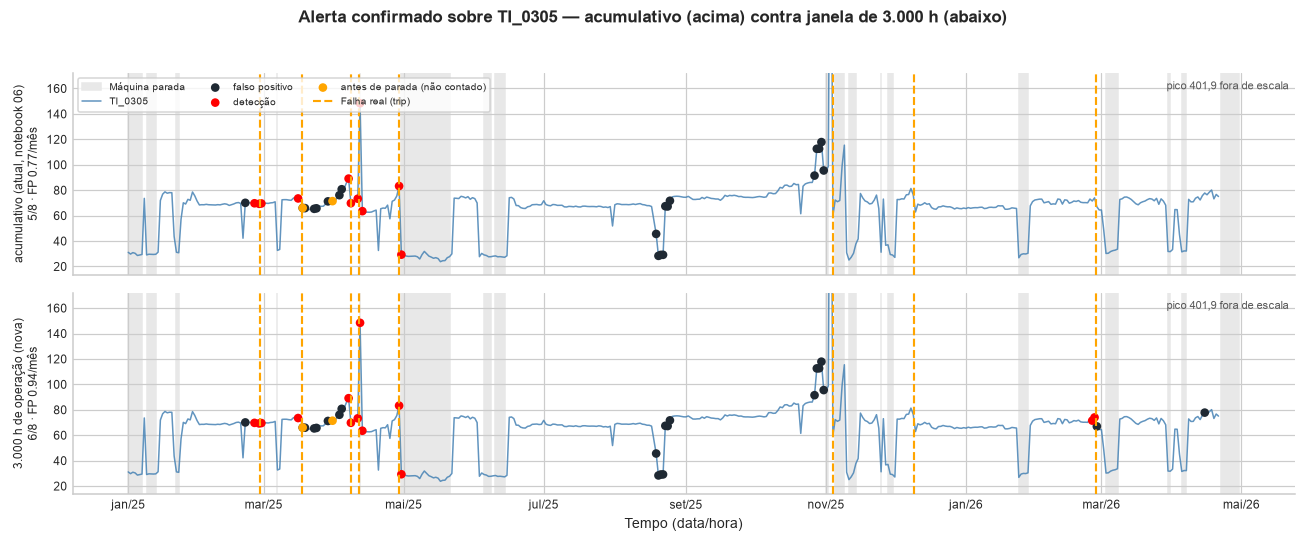

In [8]:
FREQUENCIA = "1D"          # um ponto por dia mantém os 16 meses legíveis
SENSOR = "954005_624_TI_0305"   # o mancal que dá nome à falha apresentada

with estilo_transpetro():
    fig, axes = viz.plt.subplots(len(rodadas), 1, sharex=True,
                                 figsize=(viz.LARGURA, viz.ALTURA_PAINEL * len(rodadas)))
    for eixo, (nome, r) in zip(axes, rodadas.items()):
        serie = viz.decimar(r.sensors[SENSOR], FREQUENCIA, "median")
        pontos = viz.pontos_por_tipo(r, FREQUENCIA)
        primeiro = eixo is axes[0]

        viz.sombrear_paradas(eixo, r.operability, FREQUENCIA, rotulo=primeiro)
        eixo.plot(serie.index, serie.to_numpy(), color=viz.COR_SERIE, linewidth=1.0,
                  alpha=0.85, label=SENSOR.replace("954005_624_", "") if primeiro else None)
        for tipo, quando in pontos.items():
            valores = serie.reindex(quando).dropna()
            if valores.empty:
                continue
            eixo.scatter(valores.index, valores.to_numpy(), s=32, zorder=4,
                         color=viz.CORES_EPISODIO[tipo], edgecolor="none",
                         label=tipo if primeiro else None)
        viz.marcar_eventos(eixo, r.events,
                           rotulo="Falha real (trip)" if primeiro else None)
        viz._ylim_robusto(eixo, serie)
        m = r.metrics
        eixo.set_ylabel(f"{nome}\n{m['eventos_detectados']}/8 · FP {m['fp_por_mes']}/mês",
                        fontsize=8)
        if primeiro:
            h, l = eixo.get_legend_handles_labels()
            eixo.legend(h, l, loc="upper left", fontsize=6.5, ncol=3, frameon=True)

    axes[-1].set_xlabel("Tempo (data/hora)")
    viz._formatar_eixo_x(axes[-1], serie.index)
    fig.suptitle(f"Alerta confirmado sobre {SENSOR.replace('954005_624_', '')} — "
                 "acumulativo (acima) contra janela de 3.000 h (abaixo)",
                 fontsize=11, fontweight="bold")
    fig.tight_layout(rect=viz.RECT_TITULO)
    viz.plt.show()

### Os quatro sensores, na política vencedora

Mesma leitura, agora com o painel de todos os sensores do panorama, só para a janela de
3.000 h. É a figura equivalente à do notebook 06, com a política nova.

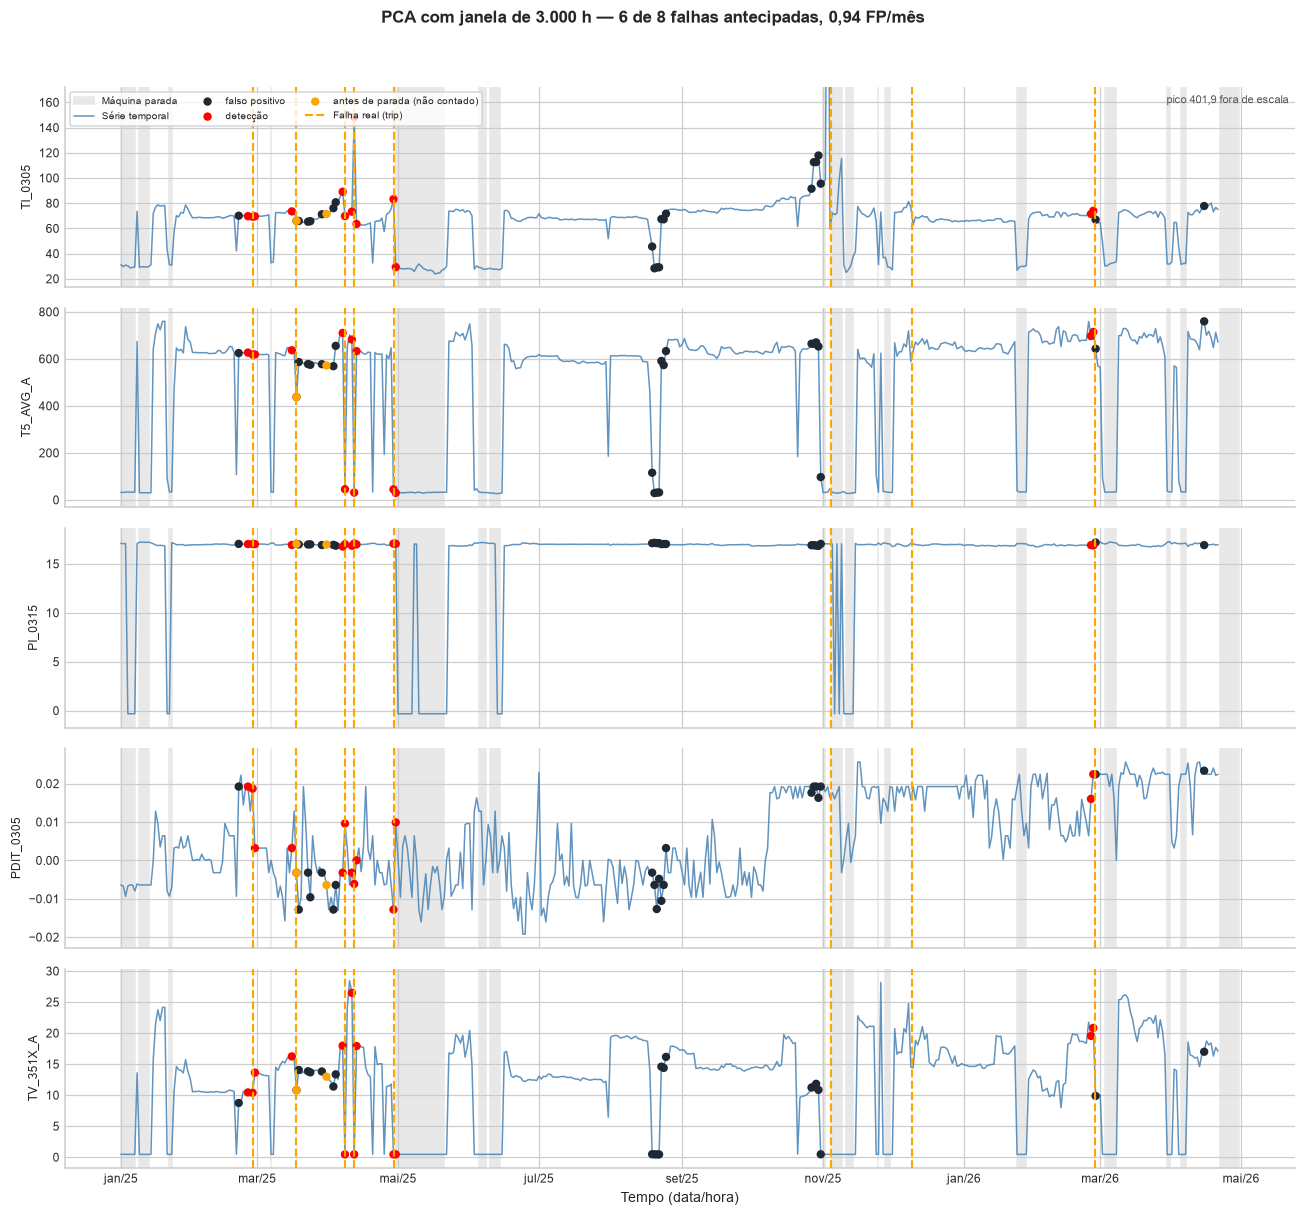

In [9]:
vencedora = rodadas["3.000 h de operação (nova)"]

with estilo_transpetro():
    sensores = viz.decimar(vencedora.sensors[SENSORS_OVERVIEW], FREQUENCIA, "median")
    pontos = viz.pontos_por_tipo(vencedora, FREQUENCIA)

    fig, axes = viz.plt.subplots(len(sensores.columns), 1, sharex=True,
                                 figsize=(viz.LARGURA, viz.ALTURA_PAINEL * 4.5))
    for i, coluna in enumerate(sensores.columns):
        eixo, serie = axes[i], sensores[coluna]
        viz.sombrear_paradas(eixo, vencedora.operability, FREQUENCIA, rotulo=(i == 0))
        eixo.plot(serie.index, serie.to_numpy(), color=viz.COR_SERIE, linewidth=1.0,
                  alpha=0.85, label="Série temporal" if i == 0 else None)
        for tipo, quando in pontos.items():
            valores = serie.reindex(quando).dropna()
            if valores.empty:
                continue
            eixo.scatter(valores.index, valores.to_numpy(), s=30, zorder=4,
                         color=viz.CORES_EPISODIO[tipo], edgecolor="none",
                         label=tipo if i == 0 else None)
        viz.marcar_eventos(eixo, vencedora.events,
                           rotulo="Falha real (trip)" if i == 0 else None)
        viz._ylim_robusto(eixo, serie)
        eixo.set_ylabel(coluna.replace("954005_624_", ""), fontsize=8)
        if i == 0:
            h, l = eixo.get_legend_handles_labels()
            eixo.legend(h, l, loc="upper left", fontsize=6.5, ncol=3, frameon=True)

    axes[-1].set_xlabel("Tempo (data/hora)")
    viz._formatar_eixo_x(axes[-1], sensores.index)
    fig.suptitle("PCA com janela de 3.000 h — 6 de 8 falhas antecipadas, 0,94 FP/mês",
                 fontsize=11, fontweight="bold")
    fig.tight_layout(rect=viz.RECT_TITULO)
    viz.plt.show()

### Por que a janela muda o resultado: o limiar em escada

O limite de cada sinal é o percentil do baseline **daquele mês**, então ele é uma linha
em escada. É aqui que a política age: com o acumulativo o baseline só cresce, cada mês
novo pesa menos, e a escada congela. Com janela de 3.000 h o histórico antigo sai, e o
limite volta a acompanhar o processo.

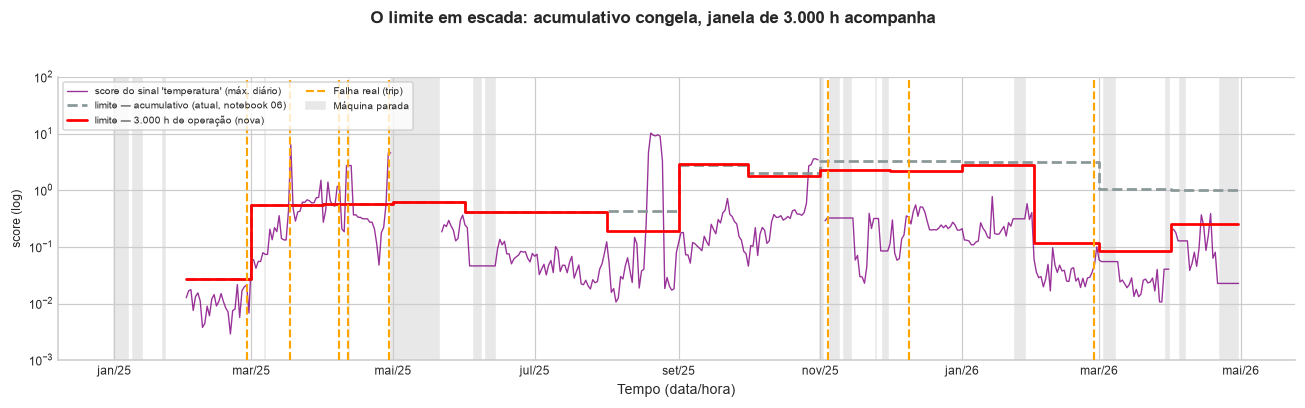

In [10]:
SINAL = "temperatura"

with estilo_transpetro():
    fig, eixo = viz.plt.subplots(figsize=(viz.LARGURA, viz.ALTURA_PAINEL * 1.5))
    score = viz.decimar(vencedora.scores[SINAL], FREQUENCIA, "max")
    eixo.plot(score.index, score.to_numpy(), color=viz.COR_SCORE, linewidth=0.9,
              alpha=0.8, label=f"score do sinal '{SINAL}' (máx. diário)")

    for nome, r in rodadas.items():
        limite = viz.decimar(r.limits[SINAL], FREQUENCIA, "max")
        estilo = "-" if "3.000" in nome else "--"
        eixo.step(limite.index, limite.to_numpy(), where="post", linestyle=estilo,
                  color=viz.COR_LIMITE if "3.000" in nome else CINZA,
                  linewidth=1.8, label=f"limite — {nome}")

    viz.marcar_eventos(eixo, vencedora.events, rotulo="Falha real (trip)")
    viz.sombrear_paradas(eixo, vencedora.operability, FREQUENCIA, rotulo=True)
    viz._ylim_log(eixo, score)
    eixo.set_yscale("log")
    eixo.set_ylabel("score (log)", fontsize=8)
    eixo.set_xlabel("Tempo (data/hora)")
    eixo.legend(loc="upper left", fontsize=6.5, ncol=2, frameon=True)
    viz._formatar_eixo_x(eixo, score.index)
    fig.suptitle("O limite em escada: acumulativo congela, janela de 3.000 h acompanha",
                 fontsize=11, fontweight="bold")
    fig.tight_layout(rect=viz.RECT_TITULO)
    viz.plt.show()

---
## 6. A arquitetura depende da política

Esta seção usa a varredura de arquiteturas (estágio 1b): 9 arquiteturas × 3 políticas.
Cruzar com três políticas e não com uma foi deliberado, e a figura mostra por quê.

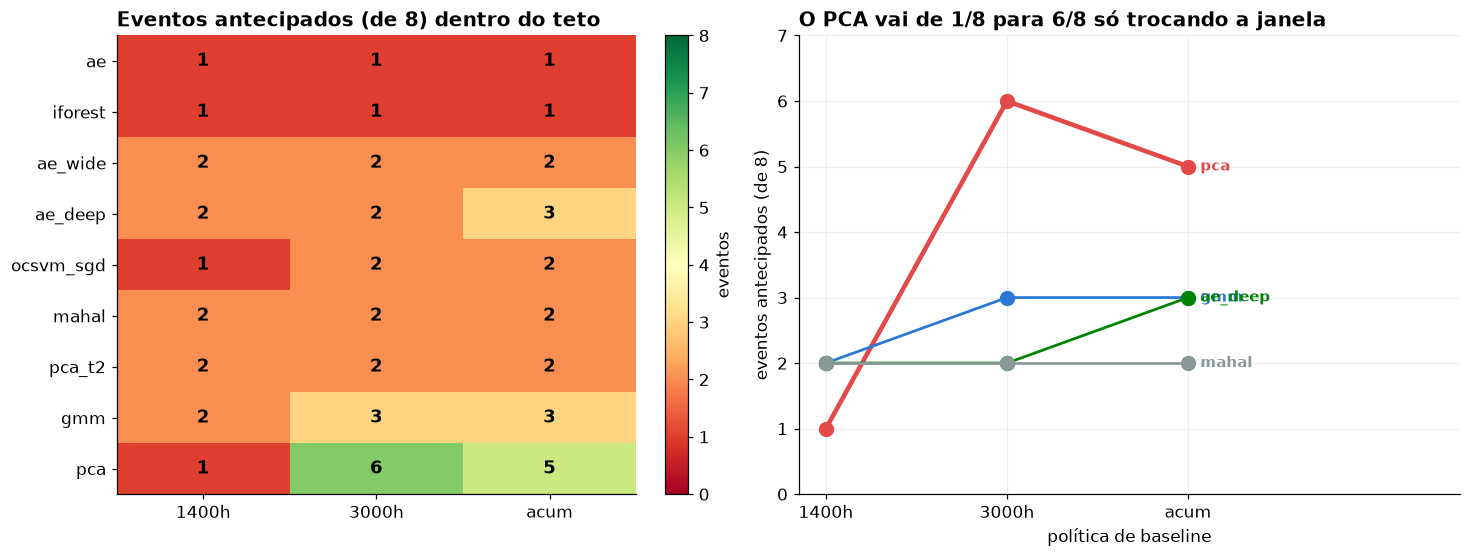

trial.baseline_label  1400h  3000h  acum
trial.model                             
ae                        1      1     1
iforest                   1      1     1
ae_wide                   2      2     2
ae_deep                   2      2     3
ocsvm_sgd                 1      2     2
mahal                     2      2     2
pca_t2                    2      2     2
gmm                       2      3     3
pca                       1      6     5


In [11]:
mapa_arq = (arq[arq.aprovado]
            .pivot_table(index="trial.model", columns="trial.baseline_label",
                         values="eventos_detectados", aggfunc="max")
            .fillna(0))
mapa_arq = mapa_arq[["1400h", "3000h", "acum"]]
mapa_arq = mapa_arq.sort_values("3000h", ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.2),
                               gridspec_kw={"width_ratios": [1, 1.15]})

imagem = ax1.imshow(mapa_arq.values, cmap="RdYlGn", vmin=0, vmax=8, aspect="auto")
ax1.set_xticks(range(len(mapa_arq.columns)), mapa_arq.columns)
ax1.set_yticks(range(len(mapa_arq.index)), mapa_arq.index)
for i in range(mapa_arq.shape[0]):
    for j in range(mapa_arq.shape[1]):
        ax1.text(j, i, f"{int(mapa_arq.iat[i, j])}", ha="center", va="center",
                 fontsize=12, fontweight="bold")
ax1.grid(False)
ax1.set_title("Eventos antecipados (de 8) dentro do teto", loc="left",
              fontweight="bold")
fig.colorbar(imagem, ax=ax1, fraction=0.046, label="eventos")

# a inversão: a mesma arquitetura em duas políticas
for arquitetura, cor, largura in [("pca", VERM, 3.0), ("gmm", AZUL, 1.8),
                                  ("ae_deep", VERD, 1.8), ("mahal", CINZA, 1.8)]:
    if arquitetura not in mapa_arq.index:
        continue
    linha = mapa_arq.loc[arquitetura]
    ax2.plot(range(len(linha)), linha.values, color=cor, lw=largura, marker="o",
             ms=9, label=arquitetura)
    ax2.annotate(arquitetura, xy=(len(linha) - 1, linha.iloc[-1]), xytext=(8, 0),
                 textcoords="offset points", color=cor, fontweight="bold", fontsize=10,
                 va="center")
ax2.set_xticks(range(len(mapa_arq.columns)), mapa_arq.columns)
ax2.set_xlim(-0.15, len(mapa_arq.columns) + 0.5)
ax2.set_ylabel("eventos antecipados (de 8)")
ax2.set_yticks(range(0, 8))
ax2.set_xlabel("política de baseline")
ax2.set_title("O PCA vai de 1/8 para 6/8 só trocando a janela", loc="left",
              fontweight="bold")
fig.tight_layout()
plt.show()

print(mapa_arq.astype(int).to_string())

**Leitura.** O PCA faz **1 de 8 em 1.400 h e 6 de 8 em 3.000 h**. Se a varredura de
arquiteturas tivesse fixado uma política — e fosse a de 1.400 h — o PCA seria
descartado como a pior arquitetura do conjunto, empatado com o IsolationForest.

Nenhuma das seis arquiteturas novas (Hotelling T², Mahalanobis, GMM, IsolationForest,
One-Class SVM linear, e as duas variantes de autoencoder) passou de 3/8. O custo delas
foi baixo — o Mahalanobis ajusta em 0,06 s contra 2,11 s do autoencoder — e a
informação é útil: não vale investir mais nesse eixo antes de resolver a política e o
sinal.

### Mas há um artefato aqui, e ele condena o método da varredura

O autoencoder aparece com **1 de 8** nesta tabela. No refino, com a mesma janela, ele
chega a **6 de 8**. A célula abaixo mostra de onde vem a contradição.

In [12]:
# Onde cada arquitetura alcança o seu melhor: os fatores baratos que a config
# vencedora usou, nas duas varreduras.
def melhor_config(tabela, modelo, janela=None):
    sub = tabela[tabela.aprovado & (tabela["trial.model"] == modelo)]
    if janela is not None:
        sub = sub[sub["trial.baseline.window_hours"] == janela]
    if sub.empty:
        return None
    return sub.sort_values(["eventos_detectados", "lead_medio_h"], ascending=False).iloc[0]

FATORES = ["trial.threshold", "trial.threshold_kind", "trial.sustain", "trial.ewma",
           "trial.confirm", "trial.exclude_alarm_h"]
linhas = []
for varredura, tabela in [("arquitetura (estágio 1b)", arq), ("refino (estágio 3)", fino)]:
    for modelo in ("pca", "ae"):
        linha = melhor_config(tabela, modelo, 3000.0)
        if linha is None:
            continue
        linhas.append({"varredura": varredura, "modelo": modelo,
                       "eventos": int(linha.eventos_detectados),
                       "lead_h": round(linha.lead_medio_h, 1),
                       **{f.replace("trial.", ""): linha[f] for f in FATORES}})
comparacao = pd.DataFrame(linhas)
print("Melhor config em 3.000 h, por varredura — o que mudou foram os FATORES BARATOS:")
print(comparacao.to_string(index=False))

# quais níveis de limiar e persistência existiam em cada varredura
print("\nníveis de limiar disponíveis:")
for nome, tabela in [("arquitetura", arq), ("refino", fino)]:
    niveis = sorted(float(v) for v in
                    tabela.loc[tabela["trial.threshold_kind"] == "percentil",
                               "trial.threshold"].unique())
    persist = sorted(tabela["trial.sustain"].unique(), key=pd.Timedelta)
    exclusao = sorted(float(v) for v in tabela["trial.exclude_alarm_h"].unique())
    print(f"  {nome:12s} percentis={niveis}")
    print(f"  {'':12s} persistência={persist}")
    print(f"  {'':12s} exclusão ao redor do alarme (h)={exclusao}")

Melhor config em 3.000 h, por varredura — o que mudou foram os FATORES BARATOS:
               varredura modelo  eventos  lead_h  threshold threshold_kind sustain  ewma  confirm  exclude_alarm_h
arquitetura (estágio 1b)    pca        6    18.3     99.900      percentil   30min    2h        2              1.0
arquitetura (estágio 1b)     ae        1    30.8     99.900      percentil   30min    1h        3              1.0
      refino (estágio 3)    pca        6    18.3     99.900      percentil   30min    2h        2              1.0
      refino (estágio 3)     ae        6    12.6     99.995      percentil   30min 30min        2              0.0

níveis de limiar disponíveis:
  arquitetura  percentis=[99.5, 99.9, 99.97]
               persistência=['30min', '2h']
               exclusão ao redor do alarme (h)=[1.0]
  refino       percentis=[99.0, 99.5, 99.9, 99.97, 99.99, 99.995]
               persistência=['30min', '1h', '2h', '4h']
               exclusão ao redor do alarme (h)=[0.

**O que aconteceu.** A varredura de arquiteturas fixou os fatores baratos em poucos
centros para caber no orçamento de tempo: percentis até 99,97 e exclusão de 1 h ao
redor de cada alarme de processo. A região boa do PCA — p99,9, persistência de 30 min —
está dentro dessa grade, e é por isso que ele apareceu com 6/8 lá.

A do autoencoder precisa de **duas** coisas que a grade grossa não tinha: limiar de
p99,995 (ela parava em p99,97) e **não** excluir a hora ao redor dos alarmes
(`exclude_alarm_h = 0`, fixado em 1,0 lá). Com as duas, ele também chega a 6/8.

Ou seja: o 1/8 do autoencoder não é uma propriedade da arquitetura, é uma consequência
de a grade grossa não conter o ponto de operação em que ele funciona. A varredura de
arquiteturas responde "qual arquitetura vence *dentro desta grade de fatores baratos*",
e eu tratei o resultado como se respondesse "qual arquitetura é melhor".

**Consequência para o método:** ranquear arquiteturas com fatores baratos grosseiros só
é válido se a grade for grossa **de forma simétrica** entre elas, e não há razão para
supor que seja. A leitura defensável é a do refino, onde PCA e autoencoder empatam em
6/8 e a escolha entre eles se decide por distribuição temporal, não por detecção.

---
## 7. O critério de "detector vivo" está mal calibrado

Além do teto de falso positivo, a busca aplica um segundo filtro: o detector não pode
ficar cego. Um detector que emudece tem falso positivo ótimo — quem não alarma não
erra. O filtro `vivo` exige silêncio máximo de 2.000 h de operação **e** alerta em ao
menos todos-menos-um dos trimestres.

Essa seção mostra que o limite de 2.000 h está errado, e por quê.

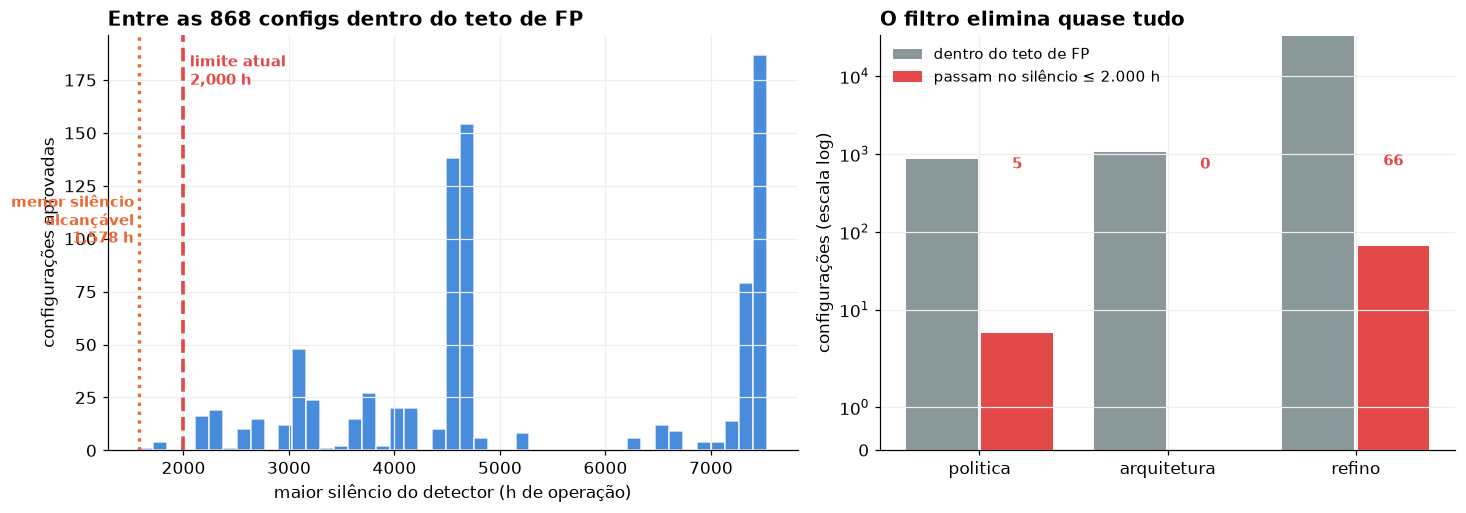

             aprovadas  vivas  trimestres_ok  % vivas
grade                                                
politica           868      5             92      0.6
arquitetura       1062      0             26      0.0
refino           32392     66           2612      0.2

percentis do silêncio entre as aprovadas (estágio 1):
count     868.0
mean     5244.0
std      1744.0
min      1578.0
1%       2194.0
5%       2587.0
25%      4125.0
50%      4729.0
max      7527.0


In [13]:
aprovadas = pol[pol.aprovado]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 4.8),
                               gridspec_kw={"width_ratios": [1.2, 1]})

ax1.hist(aprovadas.maior_silencio_h, bins=45, color=AZUL, alpha=0.85, edgecolor="white")
ax1.axvline(SILENCE_LIMIT_H, color=VERM, ls="--", lw=2.4)
ax1.text(SILENCE_LIMIT_H * 1.03, ax1.get_ylim()[1] * 0.88,
         f"limite atual\n{SILENCE_LIMIT_H:,.0f} h", color=VERM, fontsize=10,
         fontweight="bold")
minimo = aprovadas.maior_silencio_h.min()
ax1.axvline(minimo, color=LARJ, ls=":", lw=2.2)
ax1.text(minimo * 0.97, ax1.get_ylim()[1] * 0.5, f"menor silêncio\nalcançável\n{minimo:,.0f} h",
         color=LARJ, fontsize=9.5, fontweight="bold", ha="right")
ax1.set_xlabel("maior silêncio do detector (h de operação)")
ax1.set_ylabel("configurações aprovadas")
ax1.set_title(f"Entre as {len(aprovadas):,} configs dentro do teto de FP", loc="left",
              fontweight="bold")

# quem passa no limite, por grade
passa = []
for nome, tabela in grades.items():
    dentro = tabela[tabela.aprovado]
    passa.append({"grade": nome, "aprovadas": len(dentro),
                  "vivas": int((dentro.maior_silencio_h <= SILENCE_LIMIT_H).sum()),
                  "trimestres_ok": int((dentro.trimestres_com_alerta
                                        >= dentro.trimestres_avaliados - 1).sum())})
passa = pd.DataFrame(passa).set_index("grade")
passa["% vivas"] = 100 * passa.vivas / passa.aprovadas

x = np.arange(len(passa))
ax2.bar(x - 0.2, passa.aprovadas, width=0.38, color=CINZA, label="dentro do teto de FP")
ax2.bar(x + 0.2, passa.vivas, width=0.38, color=VERM, label="passam no silêncio ≤ 2.000 h")
for i, (n_apr, n_viv) in enumerate(zip(passa.aprovadas, passa.vivas)):
    ax2.text(i + 0.2, n_viv + max(passa.aprovadas) * 0.02, f"{n_viv}",
             ha="center", fontsize=10, fontweight="bold", color=VERM)
ax2.set_xticks(x, passa.index)
ax2.set_yscale("symlog")
ax2.set_ylabel("configurações (escala log)")
ax2.legend(frameon=False, fontsize=9.5)
ax2.set_title("O filtro elimina quase tudo", loc="left", fontweight="bold")
fig.tight_layout()
plt.show()

print(passa.round(1).to_string())
print("\npercentis do silêncio entre as aprovadas (estágio 1):")
print(aprovadas.maior_silencio_h.describe(percentiles=[.01, .05, .25, .5]).round(0).to_string())

**O diagnóstico.** Entre as 868 configurações que respeitam o teto de falso positivo,
o menor silêncio alcançável é 1.578 h e o percentil 1 é 2.194 h. O limite de 2.000 h
não está "3× acima do espaçamento confortável" como o comentário no código afirma —
está no **piso do que é fisicamente possível**. Só 5 das 868 passam. Na varredura de
arquiteturas, **nenhuma das 1.062** passa, e a seleção cai no ramo de contingência que
relaxa o critério; o filtro simplesmente não atuou lá.

**A causa.** Existe um vão real de ~6 meses sem nenhum evento na série (29/04/2025 a
04/11/2025). Sob teto de 1 falso positivo por mês, o detector *tem* que ficar calado
nesse trecho. O `maior_silencio_h` está punindo exatamente o comportamento que o teto
de falso positivo exige — ele confunde "cego" com "corretamente quieto".

**A prova está no próprio campeão.** A configuração de 6/8 alarma em **6 dos 6
trimestres** e ainda assim reprova, por causa de um único trecho de 2.253 h. As duas
metades do critério discordam, e a dos trimestres é a defensável.

**Correção proposta:** trocar o limite absoluto pelo maior vão entre eventos
consecutivos como referência, medido em horas de operação. Enquanto isso, os rankings
deste notebook são lidos sobre `aprovado` apenas.

---
## 8. Que eventos continuam invisíveis

O ganho de 5/8 para 6/8 é real, mas dois eventos não são pegos por nenhuma
configuração de nenhuma política. Saber *quais* muda o que fazer em seguida: evento
que ninguém pega não precisa de ajuste de limiar, precisa de sinal novo.

mecanismos derivados do replay: {'2025-02-27': 'selagem', '2025-03-17': 'mancal', '2025-04-07': 'mancal', '2025-04-11': 'mancal', '2025-04-29': 'mancal', '2025-11-04': 'oleo', '2025-12-09': 'mancal', '2026-02-26': 'oleo'}


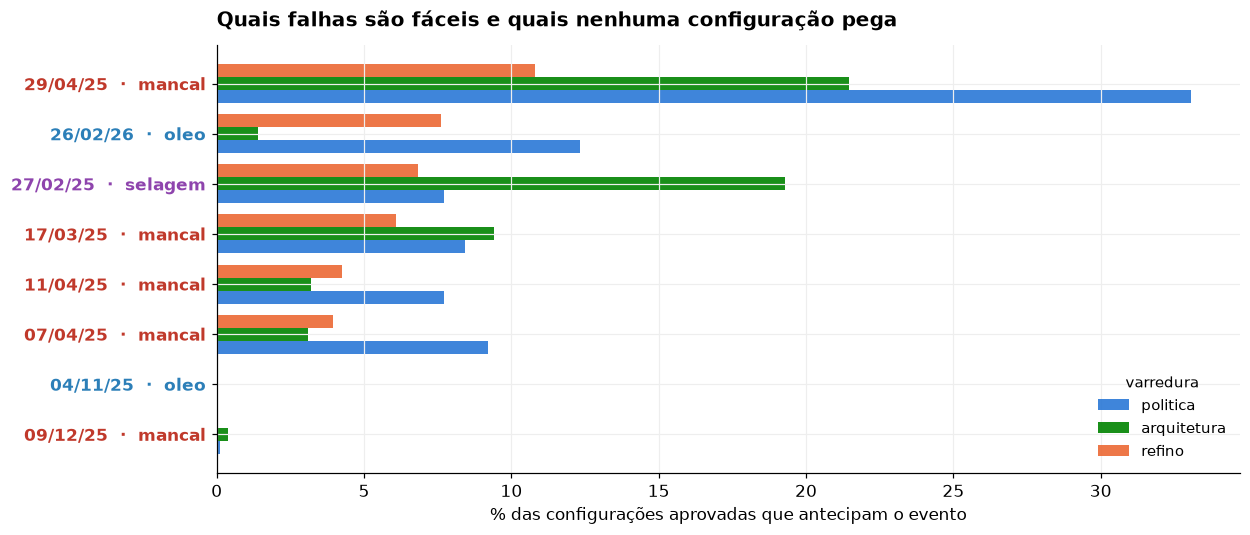

eventos que NENHUMA configuração aprovada antecipou, em nenhuma das 3 grades:
  04/11/25  (oleo)


In [14]:
# O mecanismo vem do replay e não de uma lista digitada: os eventos são DERIVADOS
# dos dados (parada >= 2 h + alarme de nível), então qualquer lista fixa aqui
# silenciosamente desatualiza se o critério de derivação mudar.
MECANISMOS = {f"{linha.falha:%Y-%m-%d}": linha.mecanismo
              for linha in referencia.reset_index().itertuples()}
CORES_MEC = {"mancal": "#c0392b", "oleo": "#2c7fb8", "selagem": "#8e44ad"}
print("mecanismos derivados do replay:", MECANISMOS)

linhas = []
for dia, mecanismo in MECANISMOS.items():
    for nome, tabela in grades.items():
        coluna = next((c for c in tabela.columns
                       if c.startswith("leads.") and dia in c), None)
        dentro = tabela[tabela.aprovado]
        taxa = 100 * dentro[coluna].notna().mean() if coluna is not None else 0.0
        linhas.append({"evento": f"{pd.Timestamp(dia):%d/%m/%y}", "mecanismo": mecanismo,
                       "grade": nome, "taxa": taxa,
                       "lead": dentro[coluna].max() if coluna is not None else np.nan})
det = pd.DataFrame(linhas)
tabela_taxa = det.pivot_table(index=["mecanismo", "evento"], columns="grade",
                              values="taxa").reindex(columns=list(grades))
tabela_taxa = tabela_taxa.sort_values("refino")

fig, ax = plt.subplots(figsize=(11.5, 5))
y = np.arange(len(tabela_taxa))
largura = 0.26
for i, grade in enumerate(tabela_taxa.columns):
    ax.barh(y + (i - 1) * largura, tabela_taxa[grade], height=largura,
            label=grade, color=[AZUL, VERD, LARJ][i], alpha=0.9)
rotulos = [f"{ev}  ·  {mec}" for mec, ev in tabela_taxa.index]
ax.set_yticks(y, rotulos)
for i, (mec, _) in enumerate(tabela_taxa.index):
    ax.get_yticklabels()[i].set_color(CORES_MEC[mec])
    ax.get_yticklabels()[i].set_fontweight("bold")
ax.set_xlabel("% das configurações aprovadas que antecipam o evento")
ax.legend(frameon=False, fontsize=10, title="varredura", title_fontsize=9.5)
ax.set_title("Quais falhas são fáceis e quais nenhuma configuração pega", loc="left",
             fontweight="bold", fontsize=13, pad=12)
fig.tight_layout()
plt.show()

nunca = tabela_taxa[(tabela_taxa.fillna(0) == 0).all(axis=1)]
print("eventos que NENHUMA configuração aprovada antecipou, em nenhuma das 3 grades:")
for mec, ev in nunca.index:
    print(f"  {ev}  ({mec})")

**Leitura.** Um único evento resiste a todas as 60.048 configurações das três grades:
**04/11/2025**. E ele tem uma explicação já medida que não é do modelo — o compressor
operou apenas **15,3 h das 48 h** da janela em que o crédito de detecção é dado. É
pouco tempo de observação para qualquer detector, e o tratamento correto é
reclassificar como *não observável*, não como falha perdida.

O de 09/12/2025, que também não aparece na melhor configuração, **é** detectado por
outras configurações aprovadas — inclusive pela vencedora da varredura de políticas,
com 7,6 h de antecedência. Não é um evento invisível, é um evento que compete com os
outros: nenhuma configuração pega ele e os cinco primeiros ao mesmo tempo dentro do
teto de falso positivo. Isso é um problema de capacidade do sinal, não de cegueira.

---
## O que este notebook conclui

| pergunta | resposta |
|---|---|
| janela móvel bate o acumulativo? | **sim**, mas só em ~3.000 h: 6/8 contra 5/8 |
| onde exatamente está o ganho? | na falha **mais recente** (26/02/2026, 19,9 h de antecedência); os 5 eventos antigos têm lead idêntico nas duas políticas |
| qual o preço? | FP de 0,77 para 0,94/mês, e 3 episódios de alerta a mais em 16 meses |
| contar em meses de calendário? | **não** — 60 d dá 3/8, 90 d dá 1/8, 30 d não aprova nada |
| teto de idade ajuda? | **não** — `3000h+idade180d` é idêntico a `3000h`, o eixo é inerte |
| qual arquitetura? | **PCA ou autoencoder**, empatados em 6/8 no refino; o PCA se defende melhor por distribuir no tempo (6 de 6 trimestres contra 4 de 6) |
| a varredura de arquiteturas resolveu isso? | **não** — a grade grossa de fatores baratos não continha o ponto de operação do autoencoder, e o 1/8 dele é artefato |
| as 6 arquiteturas novas ajudaram? | **não** — nenhuma passou de 3/8, mas ver a ressalva acima |
| o resultado é definitivo? | **não** — 3.000 h trunca até 7 dos 15 retreinos |

**Configuração recomendada** para o próximo notebook 06: PCA, janela de 3.000 h de
operação, grade de 2 min, EWMA de 2 h, limiar p99,9, persistência de 30 min,
confirmação de 2 sinais. Entrega 6/8 eventos, antecedência média de 18,3 h e
0,94 falso positivo por mês.

**Próximos passos, em ordem de retorno:**

1. **Partida a quente com 2024** — sem isso não se sabe se 3.000 h é o ótimo ou apenas
   o teto do histórico disponível. O dataset `58a4c230` serve, com três obstáculos já
   medidos: fuso misto (2024 em UTC, 2022/2025/2026 em UTC−3), colunas sem o prefixo
   `954005_624_`, e 2023 ausente.
2. **Corrigir o critério `vivo`** — limite de silêncio relativo ao maior vão entre
   eventos, no lugar das 2.000 h fixas.
3. **Refazer a comparação de arquiteturas com a grade fina** — o ranking do estágio 1b
   não é válido, porque a grade grossa favoreceu quem tinha a região boa dentro dela.
   Custa mais tempo de fila, mas é a única forma de saber se PCA e autoencoder
   realmente empatam.
4. **Mover o veto de sensor congelado** da pontuação para a elegibilidade do baseline
   (5,41% do baseline da família pressão/óleo está sob veto).